# 교보문고 6월 Top100 종합 베스트 셀러 리스트 내 랭킹과 평점 상관관계

- 랭킹 집계기간: 2026. 06. 03 ~ 2026. 06. 30
한달간의 베스트 셀러 Top100의 판매 랭킹과 평점(max 10) 집계 트렌드를 보았을 때, 책의 평점과 판매랑 순위는 유의미한 상관관계가 없다.

전체 행: 100, rating 결측으로 제외: 2, 분석에 사용: 98
--------------------------------------------------
Pearson 상관계수  r = 0.0359  (p = 0.7258)
Spearman 상관계수 rho = -0.0307  (p = 0.764)
선형회귀: rating = 0.00031 * rank + 9.6311
R^2 = 0.0013
--------------------------------------------------
결론: 통계적으로 유의미한 상관관계가 없습니다 (p >= 0.05).
count    98.000000
mean      9.646633
std       0.249713
min       8.200000
25%       9.562500
50%       9.705000
75%       9.797500
max       9.970000
Name: rating, dtype: float64

그래프 저장됨: c:\Users\cehha\ai-data-bootcamp\D010\rank_vs_rating.png


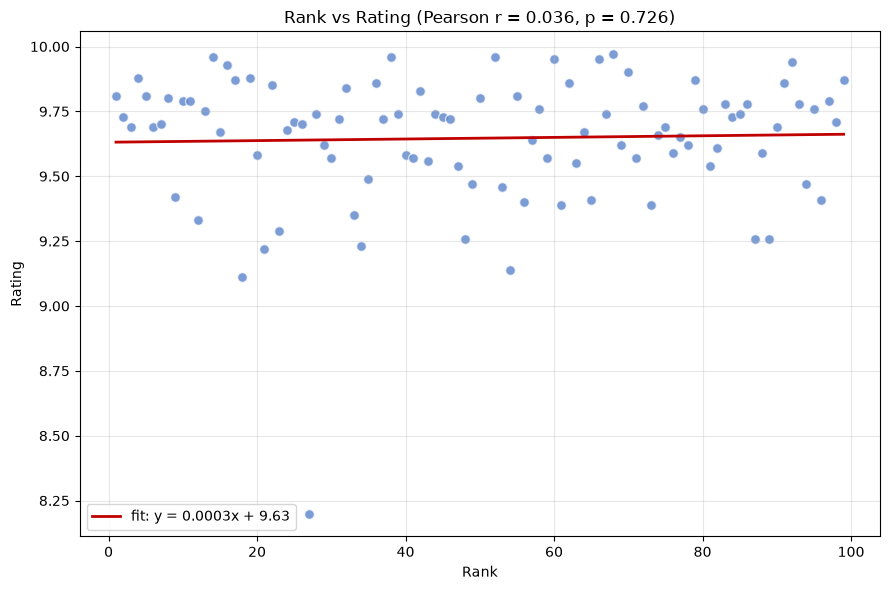

In [12]:
"""
kyobo_bestseller.csv 에서 rank와 rating 간 상관관계 분석

사용법:
    pip install pandas scipy matplotlib
    python rank_rating_correlation.py

출력:
    - 콘솔에 Pearson/Spearman 상관계수, p-value, 회귀식 출력
    - rank_vs_rating.png (산점도 + 회귀선)
"""

import sys
from pathlib import Path

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

try:
    BASE_DIR = Path(__file__).parent
except NameError:
    BASE_DIR = Path.cwd()

CSV_PATH = BASE_DIR / "kyobo_bestseller.csv"
OUTPUT_PNG = BASE_DIR / "rank_vs_rating.png"


def main():
    if not CSV_PATH.exists():
        print(f"파일을 찾을 수 없습니다: {CSV_PATH}")
        sys.exit(1)

    df = pd.read_csv(CSV_PATH)

    if "rank" not in df.columns or "rating" not in df.columns:
        print("CSV에 rank 또는 rating 컬럼이 없습니다.")
        sys.exit(1)

    total = len(df)
    d = df.dropna(subset=["rating"]).copy()
    dropped = total - len(d)

    if len(d) < 3:
        print("분석 가능한 데이터가 너무 적습니다 (rating 값이 있는 행이 3개 미만).")
        sys.exit(1)

    pearson_r, pearson_p = stats.pearsonr(d["rank"], d["rating"])
    spearman_r, spearman_p = stats.spearmanr(d["rank"], d["rating"])
    slope, intercept, r_value, p_value, std_err = stats.linregress(d["rank"], d["rating"])

    print(f"전체 행: {total}, rating 결측으로 제외: {dropped}, 분석에 사용: {len(d)}")
    print("-" * 50)
    print(f"Pearson 상관계수  r = {pearson_r:.4f}  (p = {pearson_p:.4g})")
    print(f"Spearman 상관계수 rho = {spearman_r:.4f}  (p = {spearman_p:.4g})")
    print(f"선형회귀: rating = {slope:.5f} * rank + {intercept:.4f}")
    print(f"R^2 = {r_value**2:.4f}")
    print("-" * 50)

    alpha = 0.05
    if pearson_p < alpha:
        direction = "양의" if pearson_r > 0 else "음의"
        print(f"결론: 통계적으로 유의미한 {direction} 상관관계가 있습니다 (p < {alpha}).")
    else:
        print(f"결론: 통계적으로 유의미한 상관관계가 없습니다 (p >= {alpha}).")

    print(d["rating"].describe())

    # 시각화 (한글 폰트 이슈를 피하기 위해 라벨은 영문으로 표기)
    plt.figure(figsize=(9, 6))
    plt.scatter(d["rank"], d["rating"], alpha=0.7, color="#4472C4", edgecolor="white", s=50)
    xs = np.array([d["rank"].min(), d["rank"].max()])
    plt.plot(xs, slope * xs + intercept, color="#C00000", linewidth=2,
             label=f"fit: y = {slope:.4f}x + {intercept:.2f}")
    plt.xlabel("Rank")
    plt.ylabel("Rating")
    plt.title(f"Rank vs Rating (Pearson r = {pearson_r:.3f}, p = {pearson_p:.3f})")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=150)
    print(f"\n그래프 저장됨: {OUTPUT_PNG}")


if __name__ == "__main__":
    main()

In [11]:
"""
교보문고 종합 월간 베스트셀러 크롤러 (Playwright, Python)

여러 페이지(page=1, page=2, ...)를 순서대로 돌면서 결과를 하나의 CSV에
이어서 저장합니다. 기존 CSV 파일이 있으면 마지막 순위를 읽어서 그 다음
번호부터 이어 매기고, 헤더는 다시 쓰지 않습니다.

실제 페이지의 HTML 구조(사용자 제공)를 기반으로 선택자를 맞췄습니다.

    제목: <a class="prod_link ...">제목</a>
    작가/출판사/출간일: <div class="... text-gray-800 fz-14 ...">작가 · 출판사 · <span class="date">2026.06.23</span></div>
    가격: <span class="inline-block align-top fz-16"><span class="font-bold">20,700</span><span class="font-normal">원</span></span>
    평점: <span class="font-bold text-black">9.81</span>

각 페이지의 1위 항목만 순위 뱃지가 아이콘(desc="교보문고 Best 1")으로 다르게
렌더링되기 때문에, 화면의 순위 뱃지를 파싱하는 대신 "목록에서 몇 번째로
나타나는가"로 순위를 매깁니다.

일부 책에는 오디오북/전자책 등 연관 상품으로 연결되는 "새창보기" 같은 보조
버튼이 같은 a.prod_link 선택자로 잡히는데, 텍스트가 실제 제목이 아니므로
명시적으로 걸러내고, 같은 책의 썸네일 링크가 중복으로 잡히는 경우도
href 기준으로 중복 제거합니다.

작가/가격/평점은 각 제목마다 "이 책 한 권만 담고 있는 가장 작은 조상 요소"를
먼저 찾고 그 안에서만 찾도록 스코프를 좁혀서, 목록 밖의 다른 요소가 섞여
순서가 밀리는 문제도 방지합니다.

사용법:
    1) pip install -r requirements.txt
    2) playwright install chromium
    3) 아래 CONFIG의 PAGE_URLS에 이어서 수집할 페이지 URL들을 순서대로 넣는다.
    4) python kyobo_bestseller_scraper.py
       (주피터 노트북 셀에서 실행해도 동작하도록 별도 스레드로 실행합니다)

출력:
    - kyobo_bestseller.csv (rank, title, author, publisher, pub_date, price, rating)
      APPEND=True 이고 파일이 이미 있으면 뒤에 이어붙입니다.
    - 문제 발생 시 debug/ 폴더에 스크린샷과 HTML 저장
"""

import asyncio
import csv
import re
import sys
import threading
from pathlib import Path

from playwright.sync_api import sync_playwright

# ------------------------- CONFIG -------------------------
# 이번 실행에서 순서대로 수집할 페이지들. 새 페이지를 이어서 받고 싶으면
# 이 리스트에 URL을 추가하면 된다 (예: page=2, page=3 ...).
PAGE_URLS = [
    "https://store.kyobobook.co.kr/bestseller/total/monthly?page=2&per=50",
]

TARGET_COUNT_PER_PAGE = 50

# True면 기존 kyobo_bestseller.csv 뒤에 이어붙인다 (마지막 순위 다음 번호부터).
# False면 파일을 새로 덮어쓴다 (처음부터 다시 수집할 때).
APPEND = True

try:
    BASE_DIR = Path(__file__).parent
except NameError:
    BASE_DIR = Path.cwd()

OUTPUT_CSV = BASE_DIR / "kyobo_bestseller.csv"
DEBUG_DIR = BASE_DIR / "debug"

TITLE_LINK_SELECTOR = "a.prod_link"
VALID_HREF_PATTERN = re.compile(r"^https://product\.kyobobook\.co\.kr/detail/")
RATING_PATTERN = re.compile(r"^\d(\.\d{1,2})?$")
MAX_CLIMB = 8
JUNK_TITLE_TEXTS = {"새창보기", "미리보기", "오디오북 새창보기", "전자책 새창보기"}
FIELDNAMES = ["rank", "title", "author", "publisher", "pub_date", "price", "rating"]
# ------------------------------------------------------------


def clean_text(t: str) -> str:
    return t.replace("\xa0", " ").strip()


def parse_author_block(raw_text: str):
    """'송희구 · 서삼독 · 2026.06.23' -> (author, publisher, pub_date)"""
    parts = [clean_text(p) for p in raw_text.split("·")]
    parts = [p for p in parts if p != ""]
    author = parts[0] if len(parts) > 0 else ""
    publisher = parts[1] if len(parts) > 1 else ""
    pub_date = parts[2] if len(parts) > 2 else ""
    return author, publisher, pub_date


def extract_price(raw_text: str):
    """'20,700원' -> ('20,700원', 20700)"""
    display = clean_text(raw_text)
    digits = re.sub(r"[^\d]", "", display)
    numeric = int(digits) if digits else None
    return display, numeric


def find_item_container(title_handle):
    """title_link 에서 위로 올라가며, 이 항목 하나만 담고 있는 컨테이너를 찾는다.
    조건: 그 안에 prod_link가 정확히 1개, span.date가 있고, '원' 텍스트가 포함됨."""
    node = title_handle
    for _ in range(MAX_CLIMB):
        parent_handle = node.evaluate_handle("el => el.parentElement")
        parent_el = parent_handle.as_element()
        if parent_el is None:
            return None
        node = parent_el
        title_count = len(node.query_selector_all("a.prod_link"))
        has_date = node.query_selector("span.date") is not None
        text = node.inner_text()
        if title_count == 1 and has_date and "원" in text:
            return node
    return None


def scroll_to_load_all(page, target_count):
    """일부 목록형 페이지는 스크롤해야 나머지 항목이 로드되므로,
    항목 수가 더 이상 늘지 않을 때까지 스크롤을 반복한다."""
    prev_count = -1
    stable_rounds = 0
    for _ in range(20):
        count = len(page.query_selector_all(TITLE_LINK_SELECTOR))
        if count >= target_count:
            break
        if count == prev_count:
            stable_rounds += 1
            if stable_rounds >= 3:
                break
        else:
            stable_rounds = 0
        prev_count = count
        page.mouse.wheel(0, 3000)
        page.wait_for_timeout(500)


def save_debug(page, note=""):
    DEBUG_DIR.mkdir(exist_ok=True)
    page.screenshot(path=str(DEBUG_DIR / "page_debug.png"), full_page=True)
    with open(DEBUG_DIR / "page_debug.html", "w", encoding="utf-8") as f:
        f.write(page.content())
    print(
        f"{note}\n- {DEBUG_DIR / 'page_debug.png'}\n- {DEBUG_DIR / 'page_debug.html'}"
    )


def get_last_rank_in_csv():
    """기존 CSV의 마지막 rank 값을 반환. 파일이 없거나 데이터가 없으면 0."""
    if not OUTPUT_CSV.exists():
        return 0
    last_rank = 0
    with open(OUTPUT_CSV, "r", newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                last_rank = int(row["rank"])
            except (KeyError, ValueError):
                pass
    return last_rank


def scrape_page(page, url):
    """한 페이지를 렌더링해서 (rank는 1부터 시작하는 로컬 번호로) 레코드 리스트를 반환."""
    page.goto(url, wait_until="networkidle", timeout=60000)
    try:
        page.wait_for_selector(TITLE_LINK_SELECTOR, timeout=15000)
    except Exception:
        save_debug(page, f"[{url}] 제목 링크 요소를 찾지 못했습니다.")
        return []

    scroll_to_load_all(page, TARGET_COUNT_PER_PAGE)

    raw_title_links = page.query_selector_all(TITLE_LINK_SELECTOR)

    by_href = {}
    href_order = []
    for el in raw_title_links:
        href = el.get_attribute("href") or ""
        text = clean_text(el.inner_text())
        if not text:
            continue
        if text in JUNK_TITLE_TEXTS:
            continue
        if not VALID_HREF_PATTERN.match(href):
            continue
        if href not in by_href:
            href_order.append(href)
            by_href[href] = el
        else:
            existing_text = clean_text(by_href[href].inner_text())
            if len(text) > len(existing_text):
                by_href[href] = el

    title_links = [by_href[href] for href in href_order]

    n = min(len(title_links), TARGET_COUNT_PER_PAGE)
    if n == 0:
        save_debug(page, f"[{url}] 도서 항목을 하나도 찾지 못했습니다.")
        return []

    records = []
    no_container_count = 0

    for i in range(n):
        title_el = title_links[i]
        title = clean_text(title_el.inner_text())

        container = find_item_container(title_el)

        author, publisher, pub_date = "", "", ""
        price_display, price_numeric = "", None
        rating = ""

        if container is not None:
            author_block = container.query_selector("div:has(> span.date)")
            if author_block is not None:
                author, publisher, pub_date = parse_author_block(
                    author_block.inner_text()
                )

            for span in container.query_selector_all("span"):
                text = clean_text(span.inner_text())
                if text.endswith("원") and any(c.isdigit() for c in text):
                    price_display, price_numeric = extract_price(text)
                    break

            for span in container.query_selector_all("span.font-bold.text-black"):
                text = clean_text(span.inner_text())
                if RATING_PATTERN.match(text):
                    rating = text
                    break
        else:
            no_container_count += 1

        records.append({
            "rank": i + 1,  # 나중에 main()에서 전체 offset을 더해줌
            "title": title,
            "author": author,
            "publisher": publisher,
            "pub_date": pub_date,
            "price": price_numeric if price_numeric is not None else price_display,
            "rating": rating,
        })

    if no_container_count:
        print(f"[{url}] 경고: {no_container_count}개 항목은 컨테이너를 못 찾아 일부 필드가 비어 있습니다.")

    return records


def main():
    rank_offset = get_last_rank_in_csv() if APPEND else 0
    file_exists_with_data = APPEND and OUTPUT_CSV.exists() and rank_offset > 0

    all_new_records = []

    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        page = browser.new_page(
            user_agent=(
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36"
            )
        )

        for url in PAGE_URLS:
            page_records = scrape_page(page, url)
            for r in page_records:
                rank_offset += 1
                r["rank"] = rank_offset
                all_new_records.append(r)
            print(f"[{url}] {len(page_records)}건 수집.")

        browser.close()

    if not all_new_records:
        print("새로 수집된 데이터가 없습니다.")
        return

    mode = "a" if file_exists_with_data else "w"
    with open(OUTPUT_CSV, mode, newline="", encoding="utf-8-sig") as f:
        writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
        if mode == "w":
            writer.writeheader()
        writer.writerows(all_new_records)

    action = "이어붙였습니다" if mode == "a" else "새로 저장했습니다"
    print(f"완료: {len(all_new_records)}건을 {OUTPUT_CSV} 에 {action}. (rank {all_new_records[0]['rank']}~{all_new_records[-1]['rank']})")


def run_in_thread():
    if sys.platform == "win32":
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    main()


if __name__ == "__main__":
    t = threading.Thread(target=run_in_thread)
    t.start()
    t.join()

[https://store.kyobobook.co.kr/bestseller/total/monthly?page=2&per=50] 50건 수집.
완료: 50건을 c:\Users\cehha\ai-data-bootcamp\D010\kyobo_bestseller.csv 에 이어붙였습니다. (rank 51~100)
